In [1]:
import numpy as np 
import matplotlib.pyplot as plt

from pyCollier import b0 as B0
from pyCollier import db0 as dB0
from pyCollier import c0 as C0
from pyCollier import a0 as A0

In [2]:
vev = 246.
Mh = 125
MZ = 91.1876
MW = 80.379
cw = MW/MZ
sw = np.sqrt(1-cw**2)
gL = 2*MW/vev
gy = np.sqrt(4*MZ**2/vev**2 - gL**2)

### WFR

In [3]:
@np.vectorize
def lambdas(mH, mA, mHp, mu2):
    lam1 = Mh**2 / vev**2
    lam3 = 2 * (mHp**2 - mu2**2) / vev**2
    lamH = 2 * (mH**2 - mu2**2) / vev**2
    lamA = 2 * (mA**2 - mu2**2) / vev**2
    lam4 = 1 / 2 * (lamH + lamA) - lam3
    lam5 = 1 / 2 * (lamH - lamA)
    return lam1, lam3, lam4, lam5, mu2


@np.vectorize
def IDM_WFR(mH, mA, mHp, mu2):
    lam3 = 2 * (mHp**2 - mu2**2) / vev**2
    lamH = 2 * (mH**2 - mu2**2) / vev**2
    lamA = 2 * (mA**2 - mu2**2) / vev**2
    lam4 = 1 / 2 * (lamH + lamA) - lam3
    lam5 = 1 / 2 * (lamH - lamA)
    res = -(
        1 / 4 * (lam3 + lam4 + lam5) ** 2 * vev**2 * dB0(Mh**2, mH**2, mH**2)
        + 1 / 4 * (lam3 + lam4 - lam5) ** 2 * vev**2 * dB0(Mh**2, mA**2, mA**2)
        + 1 / 2 * lam3**2 * vev**2 * dB0(Mh**2, mHp**2, mHp**2)
    )
    return -np.real(res) / (16 * np.pi**2)

In [7]:
def cHbox(l1, l3, l4, l5, mu2):
    hbar = 1 / (16 * np.pi**2)
    return (
        -1 / 6 * hbar * l3**2 / mu2**2
        - 1 / 6 * hbar * l3 * l4 / mu2**2
        + 1 / 12 * hbar * l5**2 / mu2**2
    )


def cHD(l1, l3, l4, l5, mu2):
    hbar = 1 / (16 * np.pi**2)
    return (
        - 1 / 6 * hbar * l4**2 / mu2**2
        + 1 / 6 * hbar * l5**2 / mu2**2
    )


def SMEFT_WFR(mH, mA, mHp, mu2):
    l1, l3, l4, l5, mu2 = lambdas(mH, mA, mHp, mu2)
    return vev**2*(1/4*cHD(l1, l3, l4, l5, mu2) - cHbox(l1, l3, l4, l5, mu2))

In [8]:
para = [1080, 1200, 1200, 1110]
IDM_WFR(*para), SMEFT_WFR(*para)

(array(0.00163859), np.float64(0.00030714125814051757))

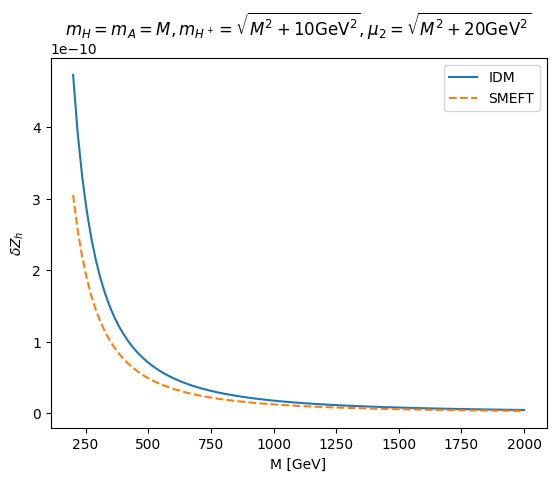

In [9]:
M_range = np.linspace(200, 2000, 100)
IDM_vals = [IDM_WFR(M, M, np.sqrt(M**2 + 10), np.sqrt(M**2 + 20)) for M in M_range]
SMEFT_vals = [SMEFT_WFR(M, M, np.sqrt(M**2 + 10), np.sqrt(M**2 + 20)) for M in M_range]

plt.plot(M_range, IDM_vals, label='IDM')
plt.plot(M_range, SMEFT_vals, label='SMEFT', linestyle='dashed')
plt.title(
    r"$m_H = m_A = M, m_{H^+} = \sqrt{M^2 + 10\text{GeV}^2}, \mu_2 = \sqrt{M^2 + 20\text{GeV}^2}$"
)
plt.xlabel('M [GeV]')
plt.ylabel(r'$\delta Z_h$')
plt.legend()
plt.show()

### hhh

In [10]:
def d1lamhhh_IDM_Honly(mH, mA, mHp, mu2):
    return (4 * mH**4 * (1 - mu2**2 / mH**2) ** 3) / (16 * np.pi**2 * vev**3)


def d1lamhhh_IDM_Aonly(mH, mA, mHp, mu2):
    return (4 * mA**4 * (1 - mu2**2 / mA**2) ** 3) / (16 * np.pi**2 * vev**3)


def d1lamhhh_IDM_Hpmonly(mH, mA, mHp, mu2):
    return (8 * mHp**4 * (1 - mu2**2 / mHp**2) ** 3) / (16 * np.pi**2 * vev**3)


def d1lamhhh_IDM(mH, mA, mHp, mu2):
    return (
        d1lamhhh_IDM_Honly(mH, mA, mHp, mu2)
        + d1lamhhh_IDM_Aonly(mH, mA, mHp, mu2)
        + d1lamhhh_IDM_Hpmonly(mH, mA, mHp, mu2)
    )


def cH(l1, l3, l4, l5, mu2):
    hbar = 1 / (16 * np.pi**2)
    return (
        -1 / 3 * hbar * l3**3 / mu2**2
        - 1 / 2 * hbar * l4 * l3**2 / mu2**2
        + 1 / 6 * hbar * l1 * l4**2 / mu2**2
        - 1 / 2 * hbar * l3 * l4**2 / mu2**2
        - 1 / 6 * hbar * l4**3 / mu2**2
        + 1 / 6 * hbar * l1 * l5**2 / mu2**2
        - 1 / 2 * hbar * l3 * l5**2 / mu2**2
        - 1 / 2 * hbar * l4 * l5**2 / mu2**2
    )
    
def d1lamhhh_SMEFT(mH, mA, mHp, mu2):
    l1, l3, l4, l5, mu2 = lambdas(mH, mA, mHp, mu2)
    return -5*vev**3*cH(l1, l3, l4, l5, mu2)

In [11]:
Mmid = 500
para = [Mmid, np.sqrt(Mmid**2 + 100**2), Mmid, np.sqrt(Mmid**2 + 100**2)]
d1lamhhh_IDM(*para), d1lamhhh_SMEFT(*para), para

(np.float64(-0.02041814050433307),
 np.float64(-0.020621285732374258),
 [500, np.float64(509.9019513592785), 500, np.float64(509.9019513592785)])

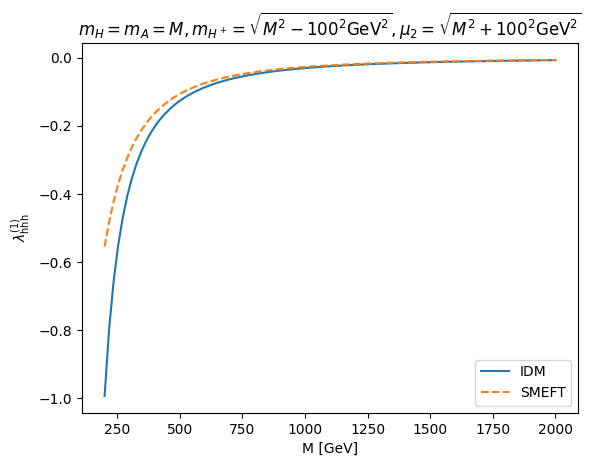

In [12]:
M_range = np.linspace(200, 2000, 100)
IDM_vals = [
    d1lamhhh_IDM(M, M, np.sqrt(M**2 - 100**2), np.sqrt(M**2 + 100**2)) for M in M_range
]
SMEFT_vals = [
    d1lamhhh_SMEFT(M, M, np.sqrt(M**2 - 100**2), np.sqrt(M**2 + 100**2))
    for M in M_range
]

plt.plot(M_range, IDM_vals, label="IDM")
plt.plot(M_range, SMEFT_vals, label="SMEFT", linestyle="dashed")
plt.title(
    r"$m_H = m_A = M, m_{H^+} = \sqrt{M^2 - 100^2\text{GeV}^2}, \mu_2 = \sqrt{M^2 + 100^2\text{GeV}^2}$"
)
plt.xlabel("M [GeV]")
plt.ylabel(r"$\lambda^{(1)}_\text{hhh}$")
plt.legend()
plt.show()

### ZH p2=0

In [13]:
@np.vectorize
def dkappaZ_IDM_p2zero(mH, mA, mHp, mu2):
    lam3 = 2 * (mHp**2 - mu2**2) / vev**2
    lamH = 2 * (mH**2 - mu2**2) / vev**2
    lamA = 2 * (mA**2 - mu2**2) / vev**2
    lam4 = 1 / 2 * (lamH + lamA) - lam3
    lam5 = 1 / 2 * (lamH - lamA)
    w = np.arccos(cw)
    res = 3 / 2 * lam3 + lam4 + 1 / 2 * lam3 * np.cos(4 * w)
    res += 1 / 2 * (-lam3 - lam4 + lam5) * B0(0, mA**2, mA**2) + 1 / 2 * (
        lam3 + lam4 - lam5
    ) * B0(0, mA**2, mH**2)
    res -= (
        1 / 4 * (lam3 + lam4 + lam5) ** 2 * vev**2 * dB0(Mh**2, mH**2, mH**2)
        + 1 / 4 * (lam3 + lam4 - lam5) ** 2 * vev**2 * dB0(Mh**2, mA**2, mA**2)
        + 1 / 2 * lam3**2 * vev**2 * dB0(Mh**2, mHp**2, mHp**2)
    )
    res += (
        (lam3 + lam4 - lam5) * mA**2 * C0(0, 0, 0, mA**2, mA**2, mH**2)
        + (lam3 + lam4 + lam5) * mA**2 * C0(0, 0, 0, mA**2, mH**2, mH**2)
        + 2 * lam3 * mHp**2 * C0(0, 0, 0, mHp**2, mHp**2, mHp**2) * np.cos(2 * w) ** 2
    )
    return np.real(res) / (16 * np.pi**2)


def cHW(l1, l3, l4, l5, mu2):
    hbar = 1 / (16 * np.pi**2)
    return 1 / 48 * hbar * gL**2 * (2 * l3 + l4) / mu2**2


def cHB(l1, l3, l4, l5, mu2):
    hbar = 1 / (16 * np.pi**2)
    return 1 / 48 * hbar * gy**2 * (2 * l3 + l4) / mu2**2


def cHWB(l1, l3, l4, l5, mu2):
    hbar = 1 / (16 * np.pi**2)
    return 1 / 24 * hbar * gL * gy * l4 / mu2**2


def dkappaZ_SMEFT_p2zero(mH, mA, mHp, mu2):
    l1, l3, l4, l5, mu2 = lambdas(mH, mA, mHp, mu2)
    hbar = 1 / (16 * np.pi**2)
    # print(
    #     vev**2 * (+gL * gy / (gL**2 + gy**2) * cHWB(l1, l3, l4, l5, mu2)),
    #     mu2**2 * cHWB(l1, l3, l4, l5, mu2),
    # )
    return vev**2 * (
        cHbox(l1, l3, l4, l5, mu2)
        + 3 / 4 * cHD(l1, l3, l4, l5, mu2)
        + 0 * gL * gy / (gL**2 + gy**2) * cHWB(l1, l3, l4, l5, mu2)
    )

In [14]:
para = [1080, 1400, 1200, 1110]
dkappaZ_IDM_p2zero(*para), dkappaZ_SMEFT_p2zero(*para)

(array(0.00186451), np.float64(0.006601565245008977))

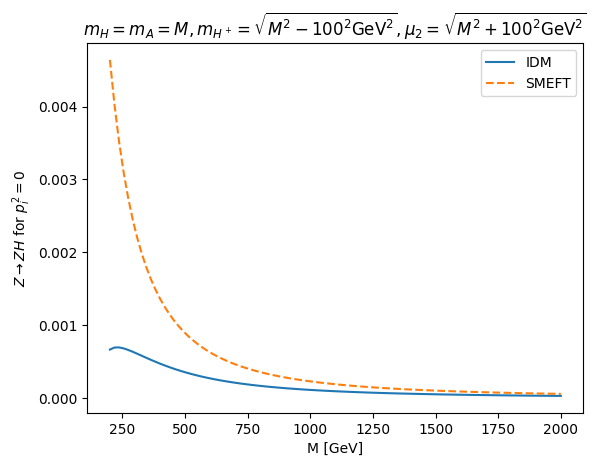

In [15]:
M_range = np.linspace(200, 2000, 100)
IDM_vals = [
    dkappaZ_IDM_p2zero(
        M, np.sqrt(M**2 + 400**2), np.sqrt(M**2 - 100**2), np.sqrt(M**2 + 100**2)
    )
    for M in M_range
]
SMEFT_vals = [
    dkappaZ_SMEFT_p2zero(
        M, np.sqrt(M**2 + 400**2), np.sqrt(M**2 - 100**2), np.sqrt(M**2 + 100**2)
    )
    for M in M_range
]

plt.plot(M_range, IDM_vals, label="IDM")
plt.plot(M_range, SMEFT_vals, label="SMEFT", linestyle="dashed")
plt.title(
    r"$m_H = m_A = M, m_{H^+} = \sqrt{M^2 - 100^2\text{GeV}^2}, \mu_2 = \sqrt{M^2 + 100^2\text{GeV}^2}$"
)
plt.xlabel("M [GeV]")
plt.ylabel(r"$Z\to ZH$ for $p_i^2 = 0$")
plt.legend()
plt.show()

### ZH p2=s

In [8]:
@np.vectorize
def ZtoZH_IDM(sqrts, mH, mA, mHp, mu2):
    S = sqrts**2
    lam3 = 2 * (mHp**2 - mu2**2) / vev**2
    lamH = 2 * (mH**2 - mu2**2) / vev**2
    lamA = 2 * (mA**2 - mu2**2) / vev**2
    lam4 = 1 / 2 * (lamH + lamA) - lam3
    lam5 = 1 / 2 * (lamH - lamA)
    w = np.arccos(cw)
    res = 1 / 2 * lam3 * (3 + np.cos(4 * w)) + lam4
    res -= (
        1 / 4 * (lam3 + lam4 + lam5) ** 2 * vev**2 * dB0(Mh**2, mH**2, mH**2)
        + 1 / 4 * (lam3 + lam4 - lam5) ** 2 * vev**2 * dB0(Mh**2, mA**2, mA**2)
        + 1 / 2 * lam3**2 * vev**2 * dB0(Mh**2, mHp**2, mHp**2)
    )
    print(res)
    #
    denom = Mh**4 + (MZ**2 - S) ** 2 - 2 * Mh**2 * (MZ**2 + S)
    resb = (
        -(
            (lam3 + lam4 - lam5)
            * (2 * mA**2 * Mh**2 + (MZ**2 - S) ** 2 - Mh**2 * (2 * mH**2 + MZ**2 + S))
            * B0(Mh**2, mA**2, mA**2)
        )
        / 2.0
    )
    resb += (
        (lam3 + lam4 + lam5)
        * (2 * mA**2 * Mh**2 - (MZ**2 - S) ** 2 + Mh**2 * (-2 * mH**2 + MZ**2 + S))
        * B0(Mh**2, mH**2, mH**2)
    ) / 2.0
    resb += +(
        -(lam5 * (mA**2 - mH**2) * (Mh**2 + MZ**2 - S))
        - (lam3 + lam4) * MZ**2 * (Mh**2 - MZ**2 + S)
    ) * B0(MZ**2, mA**2, mH**2)
    resb += (
        (-lam3 - lam4) * (Mh**2 + MZ**2 - S) * S
        - lam5 * (mA**2 - mH**2) * (Mh**2 - MZ**2 + S)
    ) * B0(S, mA**2, mH**2)
    resb += (
        (lam3 + lam4 - lam5)
        * (
            mA**4 * Mh**2
            + mH**2 * Mh**4
            + Mh**2 * (mH**2 - MZ**2) * (mH**2 - S)
            + mA**2 * ((MZ**2 - S) ** 2 - Mh**2 * (2 * mH**2 + MZ**2 + S))
        )
        * C0(Mh**2, MZ**2, S, mA**2, mA**2, mH**2)
    )
    resb += (
        (lam3 + lam4 + lam5)
        * (
            mA**4 * Mh**2
            + Mh**2 * (mH**2 - MZ**2) * (mH**2 - S)
            + mA**2 * Mh**2 * (-2 * mH**2 + Mh**2 - MZ**2 - S)
            + mH**2 * (MZ**2 - S) ** 2
        )
        * C0(S, Mh**2, MZ**2, mA**2, mH**2, mH**2)
    )
    resb += (
        lam3
        * (-((MZ**2 - S) ** 2) + Mh**2 * (MZ**2 + S))
        * B0(Mh**2, mHp**2, mHp**2)
        * np.cos(2 * w) ** 2
        + lam3
        * MZ**2
        * (-(Mh**2) + MZ**2 - S)
        * B0(MZ**2, mHp**2, mHp**2)
        * np.cos(2 * w) ** 2
    )
    resb -= lam3 * (Mh**2 + MZ**2 - S) * S * B0(S, mHp**2, mHp**2) * np.cos(2 * w) ** 2
    resb += (
        2
        * lam3
        * (
            Mh**4 * mHp**2
            + mHp**2 * (MZ**2 - S) ** 2
            + Mh**2 * (MZ**2 * S - 2 * mHp**2 * (MZ**2 + S))
        )
        * C0(Mh**2, MZ**2, S, mHp**2, mHp**2, mHp**2)
        * np.cos(2 * w) ** 2
    )
    #
    resc = (
        (1 / np.sin(w)) ** 2
        * (
            3
            * mHp**2
            * A0(mH**2)
            * (
                mA**2
                - mH**2
                + 8 * MW**2
                - 4 * (mA**2 + mH**2 - 2 * mHp**2 + 2 * MW**2) * np.cos(2 * w)
                - 5 * (mA**2 - mH**2) * np.cos(4 * w)
            )
            + 3
            * mHp**2
            * A0(mA**2)
            * (
                -(mA**2)
                + mH**2
                + 8 * MW**2
                - 4 * (mA**2 + mH**2 - 2 * mHp**2 + 2 * MW**2) * np.cos(2 * w)
                + 5 * (mA**2 - mH**2) * np.cos(4 * w)
            )
            + 4
            * (
                3
                * A0(mHp**2)
                * (
                    (
                        2 * mA**2 * mHp**2
                        + 2 * mH**2 * mHp**2
                        - 4 * mHp**4
                        - mHp**2 * MW**2
                        - 4 * MW**4
                    )
                    * np.cos(2 * w)
                    + MW**2
                    * (
                        2 * mHp**2
                        + 3 * MW**2
                        + (2 * mHp**2 + MW**2) * np.cos(4 * w)
                        - 3 * mHp**2 * np.cos(6 * w)
                    )
                )
                - 4
                * mHp**2
                * MW**2
                * (
                    3 * mA**2
                    + 3 * mH**2
                    + 9 * mHp**2
                    + 5 * MW**2
                    + (12 * mHp**2 - 5 * MW**2) * np.cos(2 * w)
                    + 9 * mHp**2 * np.cos(4 * w)
                )
                * np.sin(w) ** 2
            )
        )
    ) / (144.0 * mHp**2 * MW**2)
    resc += (
        (mA**4 + (mHp**2 - MW**2) ** 2 - 2 * mA**2 * (mHp**2 + MW**2))
        * B0(MW**2, mA**2, mHp**2)
        * np.cos(2 * w)
        * (1 / np.sin(w)) ** 2
    ) / (6.0 * MW**2)
    resc += (
        (mH**4 + (mHp**2 - MW**2) ** 2 - 2 * mH**2 * (mHp**2 + MW**2))
        * B0(MW**2, mH**2, mHp**2)
        * np.cos(2 * w)
        * (1 / np.sin(w)) ** 2
    ) / (6.0 * MW**2)
    resc += (
        B0(MZ**2, mHp**2, mHp**2)
        * np.cos(2 * w) ** 2
        * (-2 * mHp**2 - MW**2 + 6 * mHp**2 * np.cos(2 * w))
        * (1 / np.sin(w)) ** 2
    ) / 6.0
    resc -= (
        B0(MZ**2, mA**2, mH**2)
        * (
            -(mA**4)
            + 2 * mA**2 * mH**2
            - mH**4
            + 8 * mA**2 * MW**2
            + 8 * mH**2 * MW**2
            + 8 * MW**4
            + 4
            * (mA**4 + mH**4 - 6 * mH**2 * MW**2 - 2 * mA**2 * (mH**2 + 3 * MW**2))
            * np.cos(2 * w)
            + 5 * (mA**2 - mH**2) ** 2 * np.cos(4 * w)
        )
        * (1 / np.sin(w)) ** 2
    ) / (48.0 * MW**2)
    resc -= (
        MW**2
        * dB0(MZ**2, mHp**2, mHp**2)
        * np.cos(2 * w) ** 2
        * (1 / np.cos(w)) ** 2
        * (-4 * mHp**2 + MZ**2)
    ) / 3.0
    resc += (
        dB0(MZ**2, mA**2, mH**2)
        * (-((mA**2 - mH**2) ** 2) + 2 * (mA**2 + mH**2) * MZ**2 - MZ**4)
    ) / 3.0
    return np.real(res + resb / denom + resc / vev**2) / (16 * np.pi**2)


def ZtoZH_kin(sqrts):
    p1p2 = 0.5 * (sqrts**2 + MZ**2 - Mh**2)
    return p1p2**2 / MZ**4 - sqrts**2 / MZ**2 + 3


def ZtoZH_SMEFT(sqrts, mH, mA, mHp, mu2):
    p1p2 = 0.5 * (sqrts**2 + MZ**2 - Mh**2)
    l1, l3, l4, l5, mu2 = lambdas(mH, mA, mHp, mu2)
    b_gmunu = (
        cHbox(l1, l3, l4, l5, mu2)
        + 3 / 4 * cHD(l1, l3, l4, l5, mu2)
        + gL * gy / (gL**2 + gy**2) * cHWB(l1, l3, l4, l5, mu2)
    )
    b_p1p2 = (
        1
        / (gL**2 + gy**2)
        * (
            - 4 * gL**2 / (gL**2 + gy**2) * cHW(l1, l3, l4, l5, mu2)
            - 4 * gy**2 / (gL**2 + gy**2) * cHB(l1, l3, l4, l5, mu2)
            - 4 * gL * gy / (gL**2 + gy**2) * cHWB(l1, l3, l4, l5, mu2)
        )
    )
    b_SMEFT = b_gmunu * vev**2 + b_p1p2 * p1p2
    b_SM = 1
    # print(b_SMEFT, b_gmunu * vev**2, b_p1p2 * p1p2, b_SM)  # Debug print
    return b_SMEFT / b_SM
    # SMEFT_kin = b_SMEFT**2 * ZtoZH_kin(sqrts)
    # SM_kin = b_SM**2 * ZtoZH_kin(sqrts)
    # return SMEFT_kin / SM_kin - 1

In [30]:
para = [1080, 1400, 1200, 1110]
ZtoZH_IDM(220, *para), ZtoZH_SMEFT(220, *para)

0.006491746201546226 0.0066065906303619075 -0.00011484442881568103 1


(array(0.00783532), np.float64(0.006491746201546226))

In [31]:
para = [2000, 2000, 2000, 2000]
ZtoZH_IDM(220, *para), ZtoZH_SMEFT(220, *para)

0.0 0.0 -0.0 1


(array(-1.25678214e-07), np.float64(0.0))

(1.70630092214045+0j)
(1.70630092214045+0j)
(1.7374026508313314+0j)
(1.7374026508313314+0j)
(1.7625200649205282+0j)
(1.7625200649205282+0j)
(1.783918292832069+0j)
(1.783918292832069+0j)
(1.8027868596294891+0j)
(1.8027868596294891+0j)
(1.819801573539181+0j)
(1.819801573539181+0j)
(1.83537089083485+0j)
(1.83537089083485+0j)
(1.8497552856618507+0j)
(1.8497552856618507+0j)
(1.8631294841654702+0j)
(1.8631294841654702+0j)
(1.8756167282745555+0j)
(1.8756167282745555+0j)
(1.88730842379834+0j)
(1.88730842379834+0j)
(1.8982757540867548+0j)
(1.8982757540867548+0j)
(1.908576700406594+0j)
(1.908576700406594+0j)
(1.918260356556974+0j)
(1.918260356556974+0j)
(1.9273696136882295+0j)
(1.9273696136882295+0j)
(1.9359428476850538+0j)
(1.9359428476850538+0j)
(1.944014989675305+0j)
(1.944014989675305+0j)
(1.9516182127933404+0j)
(1.9516182127933404+0j)
(1.9587823798118047+0j)
(1.9587823798118047+0j)
(1.9655353420530477+0j)
(1.9655353420530477+0j)
(1.9719031462994576+0j)
(1.9719031462994576+0j)
(1.97791018525

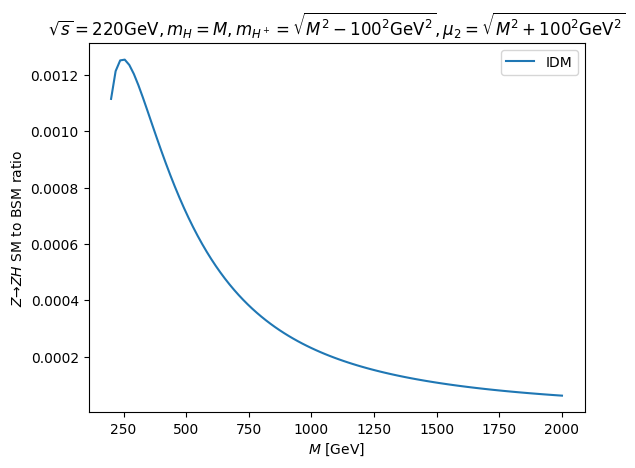

In [ ]:
M_range = np.linspace(200, 2000, 100)
sqrts_val = 220
IDM_vals = [
    ZtoZH_IDM(sqrts_val, M, np.sqrt(M**2 + 400**2), np.sqrt(M**2 - 100**2), np.sqrt(M**2 + 100**2))
    for M in M_range
]
# SMEFT_vals = [
#     ZtoZH_SMEFT(sqrts_val, M, np.sqrt(M**2 + 400**2), np.sqrt(M**2 - 100**2), np.sqrt(M**2 + 100**2))
#     for M in M_range
# ]

plt.plot(M_range, IDM_vals, label="IDM")
# plt.plot(M_range, SMEFT_vals, label="SMEFT", linestyle="dashed")
plt.title(
    r"$\sqrt{s} = 220\mathrm{GeV},m_H = M, m_{H^+} = \sqrt{M^2 - 100^2\mathrm{GeV}^2}, \mu_2 = \sqrt{M^2 + 100^2\mathrm{GeV}^2}$"
)
plt.xlabel(r"$M$ [GeV]")
plt.ylabel(r"$Z\to ZH$ SM to BSM ratio")
plt.legend()
plt.show()

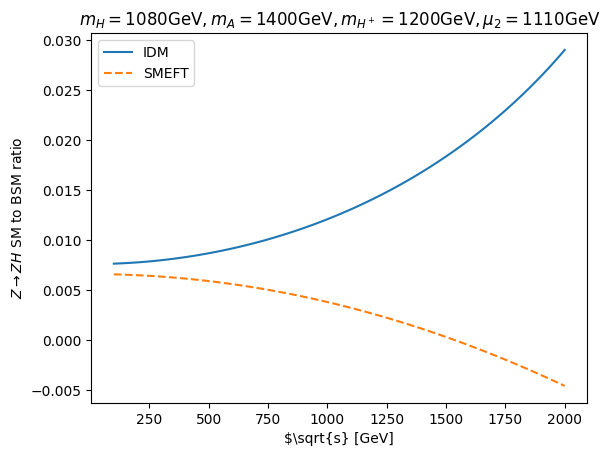

In [38]:
para = [1080, 1400, 1200, 1110]
s_range = np.linspace(100, 2000, 100)
IDM_vals = [
    ZtoZH_IDM(
        sqrts, *para
    )
    for sqrts in s_range
]
SMEFT_vals = [
    ZtoZH_SMEFT(
        sqrts, *para
    )
    for sqrts in s_range
]

plt.plot(s_range, IDM_vals, label="IDM")
plt.plot(s_range, SMEFT_vals, label="SMEFT", linestyle="dashed")
plt.title(
    r"$m_H = 1080\text{GeV}, m_A = 1400\text{GeV}, m_{H^+} = 1200\text{GeV}, \mu_2 = 1110\text{GeV}$"
)
plt.xlabel(r"$\sqrt{s} [GeV]")
plt.ylabel(r"$Z\to ZH$ SM to BSM ratio")
plt.legend()
plt.show()